In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"santhoshpparamsivans","key":"d28146a6736b6a5b281d622e91a0d271"}'}

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!kaggle datasets list

ref                                                      title                                                  size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-------------------------------------------------------  -----------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
dmahajanbe23/bmw-global-automotive-sales                 BMW Global Automotive Sales                           55017  2026-02-22 18:18:38.170000           6140        122  1.0              
thuandao/superstore-sales-analytics                      SuperStore Sales Analytics                          2283450  2026-03-06 12:31:25.800000           1645         38  1.0              
syedaeman2212/airline-ticket-prices-dataset              Airline Ticket Prices Dataset                          4409  2026-03-05 16:30:06.230000            970         33  1.0              
grandmaster07/student-exam-performance-dataset-ana

In [5]:
!kaggle datasets download -d ciplab/real-and-fake-face-detection
!unzip real-and-fake-face-detection.zip

Dataset URL: https://www.kaggle.com/datasets/ciplab/real-and-fake-face-detection
License(s): CC-BY-NC-SA-4.0
 92% 396M/431M [00:00<00:00, 490MB/s]
100% 431M/431M [00:00<00:00, 518MB/s]
Archive:  real-and-fake-face-detection.zip
  inflating: real_and_fake_face/training_fake/easy_100_1111.jpg  
  inflating: real_and_fake_face/training_fake/easy_101_0010.jpg  
  inflating: real_and_fake_face/training_fake/easy_102_0101.jpg  
  inflating: real_and_fake_face/training_fake/easy_103_1111.jpg  
  inflating: real_and_fake_face/training_fake/easy_104_1000.jpg  
  inflating: real_and_fake_face/training_fake/easy_105_1100.jpg  
  inflating: real_and_fake_face/training_fake/easy_106_0011.jpg  
  inflating: real_and_fake_face/training_fake/easy_107_1011.jpg  
  inflating: real_and_fake_face/training_fake/easy_108_1111.jpg  
  inflating: real_and_fake_face/training_fake/easy_109_1111.jpg  
  inflating: real_and_fake_face/training_fake/easy_10_0001.jpg  
  inflating: real_and_fake_face/training_fake/e

In [6]:
!ls /content/real_and_fake_face/

training_fake  training_real


In [7]:
import os

train_fake_path = '/content/real_and_fake_face/training_fake'
train_real_path = '/content/real_and_fake_face/training_real'

print("Training fake images:", len(os.listdir(train_fake_path)))
print("Training real images:", len(os.listdir(train_real_path)))

Training fake images: 960
Training real images: 1081


In [14]:
# --------------------------
# Global dataset paths
# --------------------------

# Base dataset folder
BASE_PATH = '/content/real_and_fake_face'

# Training folders
TRAIN_FAKE_PATH = f'{BASE_PATH}/training_fake'
TRAIN_REAL_PATH = f'{BASE_PATH}/training_real'

# Validation folders (optional, for later)
VALID_FAKE_PATH = f'{BASE_PATH}/validation_fake'
VALID_REAL_PATH = f'{BASE_PATH}/validation_real'

print("Dataset paths set globally!")

Dataset paths set globally!


In [15]:
import os

# Check if paths exist
print("TRAIN_FAKE_PATH exists:", os.path.exists(TRAIN_FAKE_PATH))
print("TRAIN_REAL_PATH exists:", os.path.exists(TRAIN_REAL_PATH))
print("VALID_FAKE_PATH exists:", os.path.exists(VALID_FAKE_PATH))
print("VALID_REAL_PATH exists:", os.path.exists(VALID_REAL_PATH))

# List first 5 images from training folders
print("\nSample fake images:", os.listdir(TRAIN_FAKE_PATH)[:5])
print("Sample real images:", os.listdir(TRAIN_REAL_PATH)[:5])

TRAIN_FAKE_PATH exists: True
TRAIN_REAL_PATH exists: True
VALID_FAKE_PATH exists: False
VALID_REAL_PATH exists: False

Sample fake images: ['hard_168_0011.jpg', 'mid_28_1111.jpg', 'easy_114_1110.jpg', 'easy_55_0011.jpg', 'mid_42_1111.jpg']
Sample real images: ['real_00832.jpg', 'real_00437.jpg', 'real_00460.jpg', 'real_00474.jpg', 'real_00664.jpg']


In [8]:
# Install OpenCV headless
!pip install opencv-python-headless --quiet

# Check numpy version (usually preinstalled)
import numpy as np
print("NumPy version:", np.__version__)

NumPy version: 2.0.2


In [16]:
import os

# -----------------------------
# Create structured dataset info
# -----------------------------
dataset_info = []

# Loop through folders
for label, folder in [('fake', TRAIN_FAKE_PATH), ('real', TRAIN_REAL_PATH)]:
    for file_name in os.listdir(folder):
        img_path = os.path.join(folder, file_name)
        dataset_info.append({
            'filename': file_name,
            'label': label,
            'path': img_path
        })

print("Total images:", len(dataset_info))
print("First 5 entries:")
for entry in dataset_info[:5]:
    print(entry)

Total images: 2041
First 5 entries:
{'filename': 'hard_168_0011.jpg', 'label': 'fake', 'path': '/content/real_and_fake_face/training_fake/hard_168_0011.jpg'}
{'filename': 'mid_28_1111.jpg', 'label': 'fake', 'path': '/content/real_and_fake_face/training_fake/mid_28_1111.jpg'}
{'filename': 'easy_114_1110.jpg', 'label': 'fake', 'path': '/content/real_and_fake_face/training_fake/easy_114_1110.jpg'}
{'filename': 'easy_55_0011.jpg', 'label': 'fake', 'path': '/content/real_and_fake_face/training_fake/easy_55_0011.jpg'}
{'filename': 'mid_42_1111.jpg', 'label': 'fake', 'path': '/content/real_and_fake_face/training_fake/mid_42_1111.jpg'}


In [ ]:
import random

# Shuffle the dataset in-place
random.shuffle(dataset_info)

# Check first 5 entries after shuffling
print("First 5 entries after shuffle:")
for entry in dataset_info[:5]:
    print(entry)

First 5 entries after shuffle:
{'filename': 'mid_126_1110.jpg', 'label': 'fake', 'path': '/content/real_and_fake_face/training_fake/mid_126_1110.jpg'}
{'filename': 'mid_286_1100.jpg', 'label': 'fake', 'path': '/content/real_and_fake_face/training_fake/mid_286_1100.jpg'}
{'filename': 'real_00129.jpg', 'label': 'real', 'path': '/content/real_and_fake_face/training_real/real_00129.jpg'}
{'filename': 'easy_141_0111.jpg', 'label': 'fake', 'path': '/content/real_and_fake_face/training_fake/easy_141_0111.jpg'}
{'filename': 'mid_156_1111.jpg', 'label': 'fake', 'path': '/content/real_and_fake_face/training_fake/mid_156_1111.jpg'}


In [17]:
# -----------------------------
# Split into Train and Validation
# -----------------------------
split_ratio = 0.8  # 80% train, 20% validation
total_images = len(dataset_info)
train_size = int(total_images * split_ratio)

# Train and Validation datasets
train_dataset = dataset_info[:train_size]
valid_dataset = dataset_info[train_size:]

print("Train images:", len(train_dataset))
print("Validation images:", len(valid_dataset))

# Check first 5 entries in each
print("\nSample Train entries:")
for entry in train_dataset[:5]:
    print(entry)

print("\nSample Validation entries:")
for entry in valid_dataset[:5]:
    print(entry)

Train images: 1632
Validation images: 409

Sample Train entries:
{'filename': 'hard_168_0011.jpg', 'label': 'fake', 'path': '/content/real_and_fake_face/training_fake/hard_168_0011.jpg'}
{'filename': 'mid_28_1111.jpg', 'label': 'fake', 'path': '/content/real_and_fake_face/training_fake/mid_28_1111.jpg'}
{'filename': 'easy_114_1110.jpg', 'label': 'fake', 'path': '/content/real_and_fake_face/training_fake/easy_114_1110.jpg'}
{'filename': 'easy_55_0011.jpg', 'label': 'fake', 'path': '/content/real_and_fake_face/training_fake/easy_55_0011.jpg'}
{'filename': 'mid_42_1111.jpg', 'label': 'fake', 'path': '/content/real_and_fake_face/training_fake/mid_42_1111.jpg'}

Sample Validation entries:
{'filename': 'real_00967.jpg', 'label': 'real', 'path': '/content/real_and_fake_face/training_real/real_00967.jpg'}
{'filename': 'real_00688.jpg', 'label': 'real', 'path': '/content/real_and_fake_face/training_real/real_00688.jpg'}
{'filename': 'real_00491.jpg', 'label': 'real', 'path': '/content/real_and_

In [18]:
import cv2
import numpy as np

def image_generator(dataset, as_rgb=True):
    """
    Generator to yield images one by one from a dataset list.

    Args:
        dataset (list): list of dicts with 'path' and 'label'
        as_rgb (bool): if True, converts images to RGB, else keeps original
    Yields:
        tuple: (image_array, label, filename)
    """
    for item in dataset:
        img_path = item['path']
        label = item['label']
        filename = item['filename']

        # Read image in color (BGR) by default
        img = cv2.imread(img_path, cv2.IMREAD_COLOR)
        if img is None:
            print(f"Warning: {filename} failed to load.")
            continue

        if as_rgb:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        yield img, label, filename

In [19]:
# Parameters
img_size = (64, 64)  # Resize images for uniformity
use_rgb = True       # Keep RGB for now

# Storage for processed images and labels
processed_images = []
processed_labels = []

# Create generator
train_gen = image_generator(train_dataset, as_rgb=use_rgb)

# Loop through images for processing
for img, label, fname in train_gen:
    # Resize image to fixed size
    img_resized = cv2.resize(img, img_size)

    # Flatten image to 1D array (optional for pixel analysis)
    img_flat = img_resized.flatten()

    # Store
    processed_images.append(img_flat)
    processed_labels.append(label)

    # Example: stop after first 10 for testing
    if len(processed_images) == 10:
        break

print("Processed images:", len(processed_images))
print("Shape of first image flattened:", processed_images[0].shape)
print("Corresponding labels:", processed_labels)

Processed images: 10
Shape of first image flattened: (12288,)
Corresponding labels: ['fake', 'fake', 'fake', 'fake', 'fake', 'fake', 'fake', 'fake', 'fake', 'fake']


In [20]:
import numpy as np
from PIL import Image
import os

# Example: one image path (you can loop through your dataset later)
img_path = '/content/real_and_fake_face/training_real/real_00033.jpg'

# Load image as RGB
img = Image.open(img_path).convert('RGB')
img_arr = np.array(img)  # shape: (H, W, 3), e.g., (64, 64, 3)

# Parameters
block_size = 8
H, W, C = img_arr.shape

# Split into blocks and flatten each
blocks = []
for i in range(0, H, block_size):
    for j in range(0, W, block_size):
        block = img_arr[i:i+block_size, j:j+block_size, :]  # shape: 8x8x3
        block_flat = block.flatten()  # shape: 192
        blocks.append(block_flat)

print(f"Number of blocks: {len(blocks)}")
print(f"Shape of first flattened block: {blocks[0].shape}")

Number of blocks: 5625
Shape of first flattened block: (192,)


In [21]:
import cv2
import numpy as np

BLOCK_SIZE = 8

def analyze_image(image_path):

    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    H, W, C = img.shape

    block_variances = []

    for i in range(0, H - BLOCK_SIZE + 1, BLOCK_SIZE):
        for j in range(0, W - BLOCK_SIZE + 1, BLOCK_SIZE):

            block = img[i:i+BLOCK_SIZE, j:j+BLOCK_SIZE]

            block_flat = block.flatten()

            variance = np.var(block_flat)

            block_variances.append(variance)

    image_score = np.mean(block_variances)

    return image_score

In [24]:
# Compute standard deviation (pixel inconsistency) for each block
block_sds = []

for block in blocks:
    sd = np.std(block)   # built-in NumPy function
    block_sds.append(sd)

print("First 10 block SD values:", block_sds[:10])

First 10 block SD values: [np.float64(20.725345125125312), np.float64(20.848783333639773), np.float64(20.05071085670967), np.float64(18.437281513535964), np.float64(15.474454440605491), np.float64(13.132833930265415), np.float64(27.29608742821742), np.float64(26.41542565351914), np.float64(13.70787423243379), np.float64(7.965576710219348)]


In [25]:
image_score = np.mean(block_sds)

print("Image inconsistency score:", image_score)

Image inconsistency score: 12.819291467864215


In [27]:
H, W, C = img_arr.shape
print(H, W)

600 600


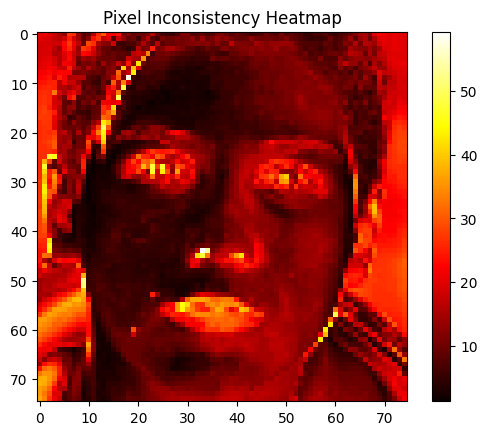

In [28]:
import numpy as np
import matplotlib.pyplot as plt

sd_grid = np.array(block_sds).reshape(75,75)

plt.imshow(sd_grid, cmap='hot')
plt.colorbar()
plt.title("Pixel Inconsistency Heatmap")
plt.show()

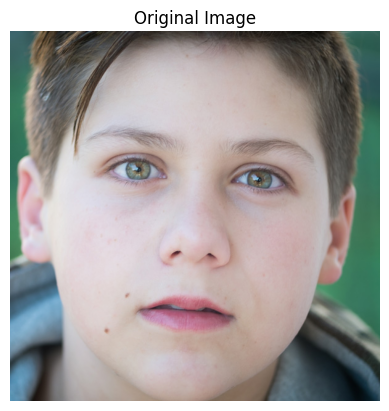

In [29]:
plt.imshow(img_arr)
plt.title("Original Image")
plt.axis("off")
plt.show()

In [31]:
real_scores = []
fake_scores = []

for item in train_dataset:

    score = analyze_image(item["path"])

    if item["label"] == "real":
        real_scores.append(score)
    else:
        fake_scores.append(score)

print("Real images:", len(real_scores))
print("Fake images:", len(fake_scores))

Real images: 672
Fake images: 960


In [32]:
import numpy as np

real_mean = np.mean(real_scores)
fake_mean = np.mean(fake_scores)

print("Real mean score:", real_mean)
print("Fake mean score:", fake_mean)

Real mean score: 704.3823585758162
Fake mean score: 692.1545851363721


In [ ]:
import numpy as np

# Convert scores to numpy arrays (if not already)
real_scores_np = np.array(real_scores)
fake_scores_np = np.array(fake_scores)

# Compute threshold: midpoint between mean real and mean fake scores
mean_real = np.mean(real_scores_np)
mean_fake = np.mean(fake_scores_np)
threshold = (mean_real + mean_fake) / 2

print(f"Mean real score: {mean_real}")
print(f"Mean fake score: {mean_fake}")
print(f"Threshold for classification: {threshold}")

# Function to predict label based on threshold
def predict_label(score):
    return "real" if score > threshold else "fake"

# Compute predictions
predictions = []
true_labels = []

for item in train_dataset:
    score = analyze_image(item["path"])  # pixel inconsistency score
    pred = predict_label(score)
    predictions.append(pred)
    true_labels.append(item["label"])

# Compute accuracy
predictions = np.array(predictions)
true_labels = np.array(true_labels)
accuracy = np.mean(predictions == true_labels)

print(f"Threshold-based accuracy: {accuracy*100:.2f}%")

Mean real score: 704.3823585758162
Mean fake score: 692.1545851363721
Threshold for classification: 698.2684718560942


In [ ]:
# Threshold from training
threshold = 698.2684718560942

# Storage for predictions
val_predictions = []
val_labels = []

# Loop through validation dataset
for item in val_dataset:
    score = analyze_image(item["path"])

    # Predict based on threshold
    pred = "real" if score > threshold else "fake"

    val_predictions.append(pred)
    val_labels.append(item["label"])

# Compute accuracy
correct = sum([p == l for p, l in zip(val_predictions, val_labels)])
accuracy = correct / len(val_labels) * 100

print(f"Validation set size: {len(val_labels)}")
print(f"Correct predictions: {correct}")
print(f"Accuracy: {accuracy:.2f}%")